In [11]:
!mamba install pandas
!mamba install numpy
!mamba install matplotlib
!mamba install seaborn
!mamba install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.1710999999940395 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.210800000011921 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.1569000000059604 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-f

In [12]:
df = pd.read_csv("Titanic-Dataset.csv")
# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# First 5 rows
print(df.head())

# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Data types
print(df.dtypes)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [13]:
# Fill missing values in Age using mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing values in Embarked using mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Check missing values again
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [14]:
# Convert Sex column into numbers
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

# Convert Embarked column into numbers
df = pd.get_dummies(df, columns=['Embarked'])

# Show first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN       False       False        True  
1          PC 17599  71.2833   C85        True       False       False  
2  STON/O2. 3101282   7.9250   NaN       False       False        True  
3   

In [15]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Standardize Age and Fare columns
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Show first 5 rows
print(df[['Age', 'Fare']].head())

        Age      Fare
0 -0.592481 -0.502445
1  0.638789  0.786845
2 -0.284663 -0.488854
3  0.407926  0.420730
4  0.407926 -0.486337


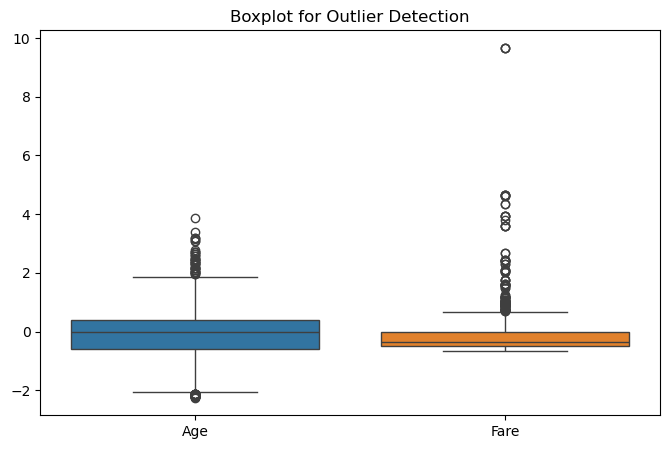

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Age', 'Fare']])

# Title
plt.title("Boxplot for Outlier Detection")

# Show graph
plt.show()

In [17]:
# Calculate Q1 and Q3
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

# Find IQR
IQR = Q3 - Q1

# Define lower and upper limit
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['Fare'] >= lower_limit) & 
        (df['Fare'] <= upper_limit)]

# Check data
print(df.shape)

(775, 14)


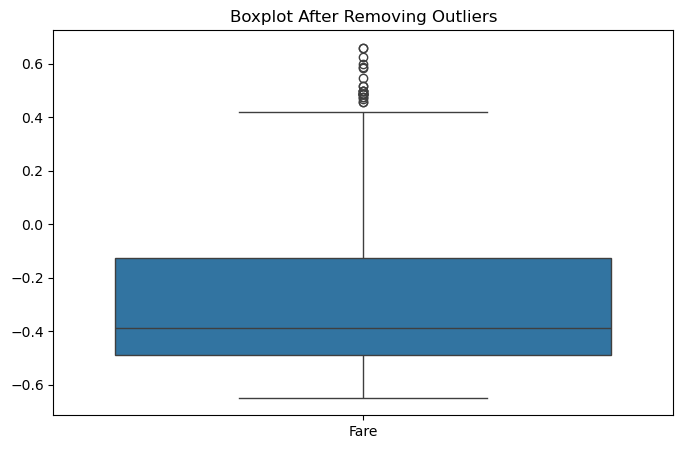

In [18]:
# Boxplot after removing outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Fare']])

plt.title("Boxplot After Removing Outliers")
plt.show()

In [19]:
# Show first 5 rows of cleaned data
print(df.head())

# Dataset information
print(df.info())

# Missing values check
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    0 -0.592481      1      0   
2                        Heikkinen, Miss. Laina    1 -0.284663      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  0.407926      1      0   
4                      Allen, Mr. William Henry    0  0.407926      0      0   
5                              Moran, Mr. James    0  0.000000      0      0   

             Ticket      Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171 -0.502445   NaN       False       False        True  
2  STON/O2. 3101282 -0.488854   NaN       False       False        True  
3            113803  0.420730  C123       False       False        True  
4     